In [3]:
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [4]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Data exploration

In [5]:
import os
def walk_through_dir(dir_path):
    """Walks though dir_path returning its contents"""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [6]:
from pathlib import Path

data_path = Path("data/pizza_sushi_steak/")
walk_through_dir(dir_path=data_path)

There are 2 directories and 0 images in data\pizza_sushi_steak
There are 3 directories and 0 images in data\pizza_sushi_steak\test
There are 0 directories and 25 images in data\pizza_sushi_steak\test\pizza
There are 0 directories and 19 images in data\pizza_sushi_steak\test\steak
There are 0 directories and 31 images in data\pizza_sushi_steak\test\sushi
There are 3 directories and 0 images in data\pizza_sushi_steak\train
There are 0 directories and 78 images in data\pizza_sushi_steak\train\pizza
There are 0 directories and 75 images in data\pizza_sushi_steak\train\steak
There are 0 directories and 72 images in data\pizza_sushi_steak\train\sushi


In [7]:
# Setup train test path
train_dir = data_path / 'train'
test_dir = data_path / 'test'

train_dir, test_dir


(WindowsPath('data/pizza_sushi_steak/train'),
 WindowsPath('data/pizza_sushi_steak/test'))

### 1.1 Visualizing image

data\pizza_sushi_steak\test\sushi\2394442.jpg
Random image path: data\pizza_sushi_steak\test\sushi\2394442.jpg
Image class: sushi


Text(0.5, 1.0, 'Image class: sushi | Image shape: torch.Size([3, 408, 512])')

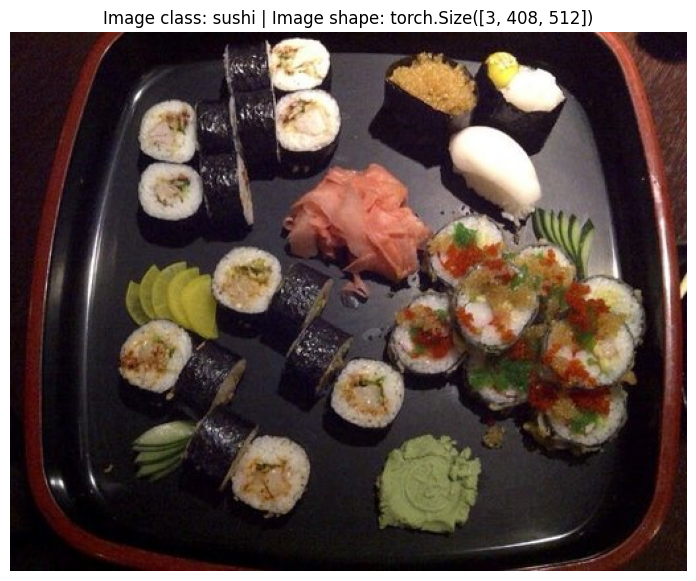

In [8]:
import random
from torchvision.io import read_image
import matplotlib.pyplot as plt
# Set seed
random.seed(42)

# 1. Get all image paths
image_path_list = list(data_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Get image class from path name
image_class = random_image_path.parent.stem
image_class

# 4. Open image
img = read_image(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1,2,0))
plt.axis(False)
plt.title(f"Image class: {image_class} | Image shape: {img.shape}")